# Exploratory Data Analysis

This is the Exploratory Data Analysis (EDA) work for the Dataset available on [kaggle `Tenhou 4-Player Riichi Mahjong Dataset`](https://www.kaggle.com/datasets/hphphp123321/tenhou-4-player-riichi-mahjong-dataset/data)

# Imports

In [12]:
import sqlite3
import gzip
import json

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import Counter

# Project imports
import sys
sys.path.append("../")

from src.utils.tile_decoder import (
    tile136_to_string,
    tile136_to_tile34,
    decode_tiles
)

from src.utils.action_decoder import (
    decode_action,
    decode_actions
)

from src.utils.state_decoder import (
    print_state
)

# Connecting to the DB

In [13]:
DB_PATH = Path("../data/raw/datasets_positive.db")

conn = sqlite3.connect(DB_PATH)

# Visualize the Schemas

In [14]:
query = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

tables = pd.read_sql(query, conn)

tables

,name
0,Skip
1,Discard
2,Chi
3,Pon
4,DaiMinKan
5,ShouMinKan
6,AnKan
7,Riichi


## Count Rows per Table

In [15]:
table_counts = {}

for table in tables["name"]:

    count_query = f"""
    SELECT COUNT(*) as count
    FROM {table}
    """

    count = pd.read_sql(
        count_query,
        conn
    ).iloc[0]["count"]

    table_counts[table] = count

table_counts

{'Skip': np.int64(30000136),
 'Discard': np.int64(50000456),
 'Chi': np.int64(9229898),
 'Pon': np.int64(13193664),
 'DaiMinKan': np.int64(77151),
 'ShouMinKan': np.int64(382783),
 'AnKan': np.int64(523304),
 'Riichi': np.int64(9668942)}

# Visualize Action Distribution

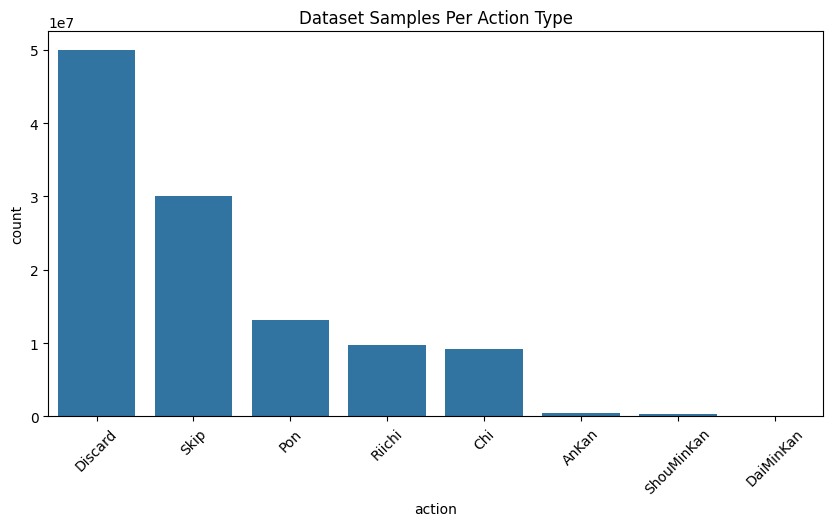

In [29]:
counts_df = pd.DataFrame({
    "action": list(table_counts.keys()),
    "count": list(table_counts.values())
})

counts_df = counts_df.sort_values(
    by="count",
    ascending=False
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=counts_df,
    x="action",
    y="count"
)

plt.title("Dataset Samples Per Action Type")
plt.xticks(rotation=45)

plt.show()

## Dataset Action Distribution Observations

The dataset is highly imbalanced across action categories. Discard actions dominate the dataset, while actions such as Pon, Chi, and Riichi appear less frequently, and Kan-related actions are comparatively rare.

However, this imbalance reflects the actual structure and strategic dynamics of Riichi Mahjong gameplay rather than a flaw in data collection.

Several observations support this:

- Most turns in Riichi Mahjong consist of discard decisions, making discard actions naturally the most common event in gameplay.

- Skilled players tend to avoid opening their hand unnecessarily, which explains the large number of Skip actions relative to calls such as Chi or Pon.

- Pon actions are more common than Chi actions because Pon can be called on discards from any opponent, while Chi can only be called on discards from the player immediately to the left. This creates fewer opportunities for Chi decisions.

- Riichi opportunities occur less frequently because players may only declare Riichi once per hand, and only under specific conditions (closed tenpai).

- Kan actions are particularly rare among stronger players due to their strategic risk. Calling Kan reveals additional dora indicators, potentially increasing opponents’ hand values and accelerating the round. As a result, Kans are often considered situational and high-risk decisions.

Therefore, although the dataset is imbalanced, the imbalance accurately reflects real gameplay distributions and expert strategic tendencies.

This observation is important for future model design, since different action types may require:
- separate models,
- action-specific balancing strategies,
- or contextual decision modeling.

Additionally, the Skip dataset is context-dependent. A Skip action only exists relative to another available action opportunity (e.g., skipping Chi, Pon, Riichi, or Kan). Therefore, Skip decisions may need to be separated according to their associated action context during future modeling

# Decoding one full Discard sample

In [17]:
query = """
SELECT *
FROM Discard
LIMIT 1
"""

df = pd.read_sql(query, conn)

blob = df.iloc[0]["Data"]

sample = json.loads(
    gzip.decompress(blob)
)

print_state(sample)

GAME STATE
Round wind: 0
Player wind: 1
Honba: 0
Riichi sticks: 0
Remaining tiles: 68

Dora indicators:
['2p']

Player hand:
['2m', '4m', '5m', '7m', '6p', '2s', '2s', '3s', '4s', 'east', 'south', 'west', 'red', '7s']

Players:

Player 0
Points: 25000
Riichi: False
Discards:
['west']

Player 1
Points: 25000
Riichi: False
Discards:
[]

Player 2
Points: 25000
Riichi: False
Discards:
[]

Player 3
Points: 25000
Riichi: False
Discards:
[]

Valid actions:
0: discard: ['2m']
1: discard: ['4m']
2: discard: ['5m']
3: discard: ['7m']
4: discard: ['6p']
5: discard: ['2s']
6: discard: ['2s']
7: discard: ['3s']
8: discard: ['4s']
9: discard: ['east']
10: discard: ['south']
11: discard: ['west']
12: discard: ['red']
13: discard: ['7s']

Expert chose:
discard: ['east']


# Valid Actions Count

In [18]:
num_samples = 5000

query = f"""
SELECT Data
FROM Discard
LIMIT {num_samples}
"""

df = pd.read_sql(query, conn)

valid_action_counts = []

for blob in df["Data"]:

    sample = json.loads(
        gzip.decompress(blob)
    )

    valid_action_counts.append(
        len(sample["valid_actions"])
    )

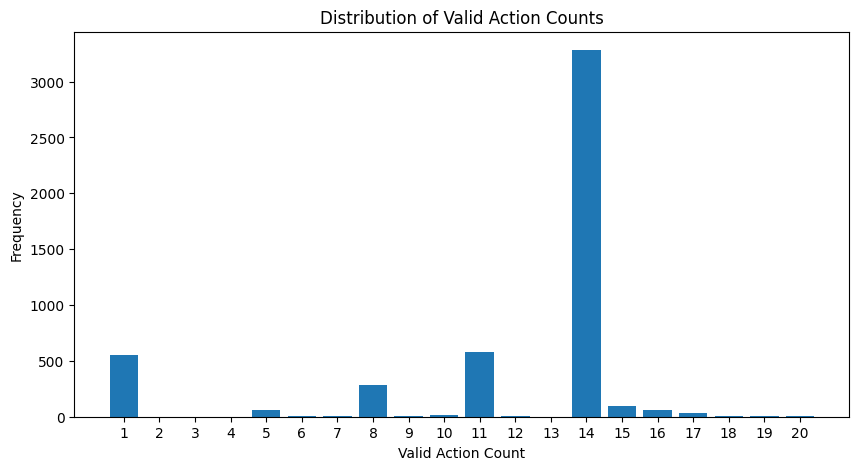

In [30]:
plt.figure(figsize=(10, 5))

bins = range(
    min(valid_action_counts),
    max(valid_action_counts) + 2
)

plt.hist(
    valid_action_counts,
    bins=bins,
    align="left",
    rwidth=0.8
)

plt.xticks(range(
    min(valid_action_counts),
    max(valid_action_counts) + 1
))

plt.xlabel("Valid Action Count")
plt.ylabel("Frequency")
plt.title("Distribution of Valid Action Counts")

plt.show()

## Valid Action Count Distribution Observations

The distribution of valid action counts reveals several important structural properties of the dataset and the Mahjong decision process.

The largest concentration occurs at 14 valid actions. This strongly suggests that, in most discard states, the player may discard any of the 14 tiles currently in hand. Since discard decisions dominate Mahjong gameplay, this behavior is expected and serves as a strong sanity check for the dataset representation.

Additional peaks appear at 11, 8, and 5 valid actions. These values correspond naturally to open-hand states after one, two, or three melds respectively:

- 11 valid actions → one open meld
- 8 valid actions → two open melds
- 5 valid actions → three open melds

This observation matches the structure of Riichi Mahjong hands, where each meld reduces the number of tiles remaining in the concealed hand.

A large concentration also appears at 1 valid action. Inspection of these states suggests they are frequently related to Riichi-locked situations, where the player is forced to tsumogiri (discard the tile just drawn) unless a winning action is available.

States containing 15–20 valid actions appear to correspond to situations where multiple action types coexist simultaneously. In particular, several of these states contain multiple Riichi declarations associated with different discard choices. This indicates that the dataset represents actions as distinct legal decisions rather than only as tile selections. For example:

- discard 5m normally
- discard 5m and declare Riichi

are treated as separate candidate actions.

This is an important observation because it suggests that the action space is structured around full legal decisions rather than isolated tile predictions.

Further inspection also revealed an important detail regarding post-call discard states. In some situations, after a player declares a Pon or Chi, the hand representation still temporarily contains the tiles used in the meld during the discard decision state. However, these tiles are not included among the valid discard actions. This likely reflects the temporal ordering of the state representation, where the discard decision is captured before the meld tiles are fully removed from the concealed hand representation.

Overall, the valid action distribution strongly suggests that:
- the dataset uses dynamic legal-action candidate sets,
- action legality is context-dependent,
- and the policy problem is better formulated as legal-action ranking rather than fixed global tile classification.

# Most Common Discard Tiles

In [25]:
discard_counter = Counter()

num_samples = 10000

query = f"""
SELECT Data
FROM Discard
LIMIT {num_samples}
"""

df = pd.read_sql(query, conn)

for blob in df["Data"]:

    sample = json.loads(
        gzip.decompress(blob)
    )

    chosen_idx = sample["action_idx"]

    action = sample["valid_actions"][chosen_idx]

    tile136 = action["tiles"][0]

    tile34 = tile136_to_tile34(tile136)

    discard_counter[tile34] += 1

In [26]:
tile_names = [
    tile136_to_string(i * 4)
    for i in range(34)
]

discard_df = pd.DataFrame({
    "tile": tile_names,
    "count": [
        discard_counter[i]
        for i in range(34)
    ]
})

discard_df

,tile,count
0,1m,419
1,2m,247
2,3m,178
3,4m,175
4,5m,154
5,6m,178
6,7m,187
7,8m,276
8,9m,378
9,1p,399


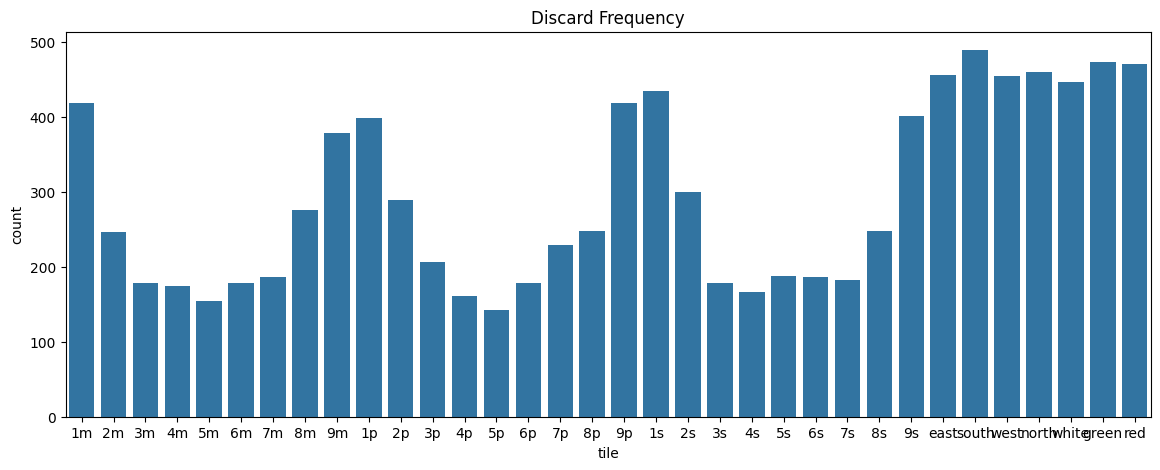

In [27]:
plt.figure(figsize=(14, 5))

sns.barplot(
    data=discard_df,
    x="tile",
    y="count"
)

plt.title("Discard Frequency")

plt.show()

## Discard Frequency Observations

The discard frequency distribution follows well-known Riichi Mahjong tile-efficiency principles and appears highly consistent with realistic expert gameplay.

Honor tiles are the most frequently discarded tiles in the dataset. This is strategically expected because honor tiles generally provide lower tile acceptance and reduced hand flexibility compared to suited tiles. Unless they contribute to valuable yaku or pairs, isolated honors are often inefficient to keep in hand.

Among suited tiles, terminal tiles (1s and 9s) are discarded more frequently than central tiles. This behavior is also expected from standard Mahjong efficiency theory:

- terminal tiles have fewer possible connections,
- central tiles participate in more sequences,
- and middle tiles contribute to higher overall tile acceptance.

The distribution gradually decreases toward the center tiles, with 5-valued tiles being the least frequently discarded. This is consistent with Mahjong strategy because 5-tiles maximize connectivity and sequence potential. Additionally, red fives increase the strategic value of 5-tiles even further, making them especially valuable to retain in hand.

Overall, the discard frequency distribution strongly suggests that the dataset reflects realistic tile-efficiency decisions made by experienced players rather than random or noisy discard behavior.

In [42]:
from src.features.state_representation import (
    extract_state_features
)

state = extract_state_features(sample)

state

{'round_wind': 0,
 'num_honba': 1,
 'num_riichi': 0,
 'player_wind': 0,
 'position': 0,
 'remain_tiles': 15,
 'dora_indicators': [7, 5],
 'hand_tiles': [1, 1, 2, 3, 3, 12, 13, 18, 19, 22, 22],
 'players': {'0': {'points': 41700,
   'riichi': False,
   'discards': [28, 27, 9, 16, 10, 6, 15, 20, 13, 32, 32, 0, 33, 33],
   'melds': [{'type': 2, 'tiles': [92, 98, 103, -1], 'who': [0, 0, 3, -1]}],
   'tsumo_giri': [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0]},
  '1': {'points': 19000,
   'riichi': False,
   'discards': [30, 27, 32, 18, 31, 17, 26, 26, 24, 2, 0, 14, 30, 10],
   'melds': [],
   'tsumo_giri': [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0]},
  '2': {'points': 20300,
   'riichi': False,
   'discards': [18, 17, 11, 16, 24, 25, 28, 23, 33, 32, 20, 7, 30, 17],
   'melds': [{'type': 5, 'tiles': [124, 126, 127, 125], 'who': [2, 2, 1, 2]},
    {'type': 2, 'tiles': [5, 13, 10, -1], 'who': [2, 2, 1, -1]}],
   'tsumo_giri': [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1]},
  '3': {'points': 19000,
